In [2]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [3]:
df =pd.read_csv("house_prices.csv")


In [4]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN


In [5]:
df.shape

(187531, 19)

In [6]:
df.describe()

,Index,Price (in rupees)
count,187531.000000,1.698660e+05
mean,93765.000000,7.583772e+03
std,54135.681003,2.724171e+04
min,0.000000,0.000000e+00
25%,46882.500000,4.297000e+03
50%,93765.000000,6.034000e+03
75%,140647.500000,9.450000e+03
max,187530.000000,6.700000e+06


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [8]:
df.isna().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
dtype: int64

## 1. Data Cleaning & Feature Engineering

The raw columns are messy text (e.g. `42 Lac`, `500 sqft`, `10 out of 11`). We parse these
into proper numeric features before doing any deeper analysis.


In [9]:
import re

def parse_amount(x):
    """Convert '42 Lac' / '1.40 Cr' strings into rupee values."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if 'Call' in x:
        return np.nan
    m = re.match(r'([\d.]+)\s*(Lac|Cr)', x)
    if not m:
        return np.nan
    val, unit = float(m.group(1)), m.group(2)
    return val * 1e5 if unit == 'Lac' else val * 1e7

def parse_sqft(x):
    if pd.isna(x):
        return np.nan
    m = re.match(r'([\d.]+)', str(x))
    return float(m.group(1)) if m else np.nan

def parse_floor(x):
    if pd.isna(x):
        return np.nan, np.nan
    m = re.match(r'(Ground|\d+)\s*out of\s*(\d+)', str(x))
    if not m:
        return np.nan, np.nan
    floor = 0 if m.group(1) == 'Ground' else float(m.group(1))
    return floor, float(m.group(2))

def parse_parking(x):
    if pd.isna(x):
        return np.nan
    nums = re.findall(r'(\d+)', str(x))
    return sum(float(n) for n in nums) if nums else np.nan

# Target: total price in rupees, parsed from 'Amount(in rupees)'
df['total_price'] = df['Amount(in rupees)'].apply(parse_amount)

# Area: prefer carpet area, fall back to super area
df['carpet_sqft'] = df['Carpet Area'].apply(parse_sqft)
df['super_sqft']  = df['Super Area'].apply(parse_sqft)
df['area_sqft']   = df['carpet_sqft'].fillna(df['super_sqft'])

# Bedrooms from the title (e.g. '2 BHK ...')
df['BHK'] = df['Title'].str.extract(r'(\d+)\s*BHK').astype(float)

# Floor number / total floors in the building
floors = df['Floor'].apply(parse_floor)
df['floor_num']    = floors.apply(lambda t: t[0])
df['total_floors'] = floors.apply(lambda t: t[1])

# Bathroom / balcony counts ('> 10' -> 11)
for c in ['Bathroom', 'Balcony']:
    df[c] = df[c].replace('> 10', '11').astype(float)

# Car parking slots (sum of open + covered counts found in the string)
df['car_parking_num'] = df['Car Parking'].apply(parse_parking)

df[['total_price','area_sqft','BHK','floor_num','total_floors','Bathroom','Balcony','car_parking_num']].describe()


,total_price,area_sqft,BHK,floor_num,total_floors,Bathroom,Balcony,car_parking_num
count,1.778470e+05,186704.000000,186610.000000,180044.000000,180044.000000,186703.000000,138596.000000,84174.000000
mean,1.198134e+07,1245.597047,2.569691,4.454028,8.777249,2.428247,2.001782,4.036935
std,3.943827e+07,2348.544838,0.786524,4.661898,7.615343,0.871107,0.958087,31.822614
min,1.000000e+05,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,4.840000e+06,800.000000,2.000000,2.000000,4.000000,2.000000,1.000000,1.000000
50%,7.800000e+06,1140.000000,3.000000,3.000000,5.000000,2.000000,2.000000,1.000000
75%,1.450000e+07,1551.000000,3.000000,6.000000,11.000000,3.000000,3.000000,1.000000
max,1.400300e+10,709222.000000,10.000000,200.000000,200.000000,11.000000,11.000000,999.000000


## 2. Cleaning Outliers & Missing Target/Area

Some listings have no parseable price ("Call for Price") or unrealistic areas (data-entry
errors with areas in the hundreds of thousands of sqft). We drop rows where the target or the
key driver (`area_sqft`) can't be trusted, and clip extreme price outliers (top luxury listings
that would otherwise dominate the model).


In [10]:
print("Missing total_price:", df['total_price'].isna().sum())
print("Missing area_sqft:", df['area_sqft'].isna().sum())
print(df['total_price'].quantile([0.001, 0.01, 0.5, 0.99, 0.999, 1.0]))


Missing total_price: 9684
Missing area_sqft: 827
0.001    9.469200e+05
0.010    1.600000e+06
0.500    7.800000e+06
0.990    7.000000e+07
0.999    1.250000e+08
1.000    1.400300e+10
Name: total_price, dtype: float64


In [11]:
df_clean = df.copy()

# Keep realistic, parseable rows
df_clean = df_clean[(df_clean['total_price'] > 1e5) & (df_clean['total_price'] < 2e8)]
df_clean = df_clean[(df_clean['area_sqft'] >= 100) & (df_clean['area_sqft'] <= 10000)]
df_clean = df_clean.dropna(subset=['total_price', 'area_sqft', 'BHK'])

# Derived feature: price per sqft (useful for EDA, not used directly as a model input
# since it's a function of the target)
df_clean['price_per_sqft'] = df_clean['total_price'] / df_clean['area_sqft']

print("Rows before cleaning:", len(df))
print("Rows after cleaning :", len(df_clean))
df_clean[['total_price','area_sqft','price_per_sqft','BHK']].describe()


Rows before cleaning: 187531
Rows after cleaning : 173129


,total_price,area_sqft,price_per_sqft,BHK
count,1.731290e+05,173129.000000,173129.000000,173129.000000
mean,1.192713e+07,1275.882995,10993.604998,2.616766
std,1.228499e+07,695.714252,16248.087866,0.760407
min,1.100000e+05,100.000000,62.678063,1.000000
25%,5.000000e+06,862.000000,4800.000000,2.000000
50%,8.000000e+06,1173.000000,6866.666667,3.000000
75%,1.500000e+07,1580.000000,11111.111111,3.000000
max,1.900000e+08,10000.000000,350000.000000,10.000000


## 3. Univariate Distributions


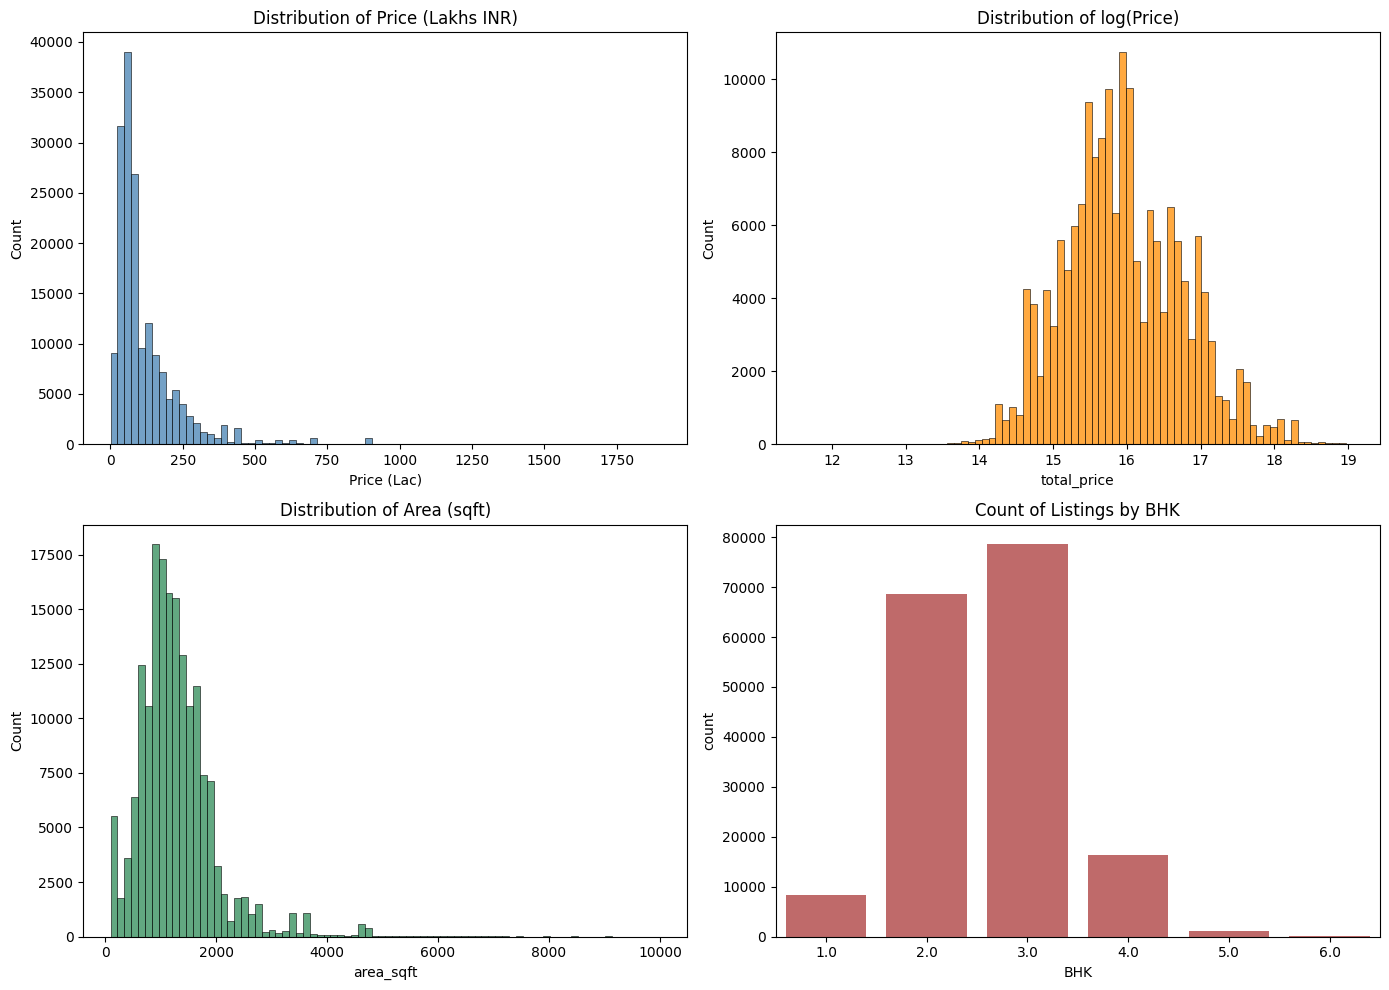

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_clean['total_price']/1e5, bins=80, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribution of Price (Lakhs INR)')
axes[0,0].set_xlabel('Price (Lac)')

sns.histplot(np.log1p(df_clean['total_price']), bins=80, ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Distribution of log(Price)')

sns.histplot(df_clean['area_sqft'], bins=80, ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Distribution of Area (sqft)')

sns.countplot(x='BHK', data=df_clean[df_clean['BHK'] <= 6], ax=axes[1,1], color='indianred')
axes[1,1].set_title('Count of Listings by BHK')

plt.tight_layout()
plt.show()


**Observation:** raw price is heavily right-skewed (a long tail of luxury properties), while
`log(price)` is close to normal. This is why we'll model `log(price)` rather than raw price.


## 4. Categorical Features


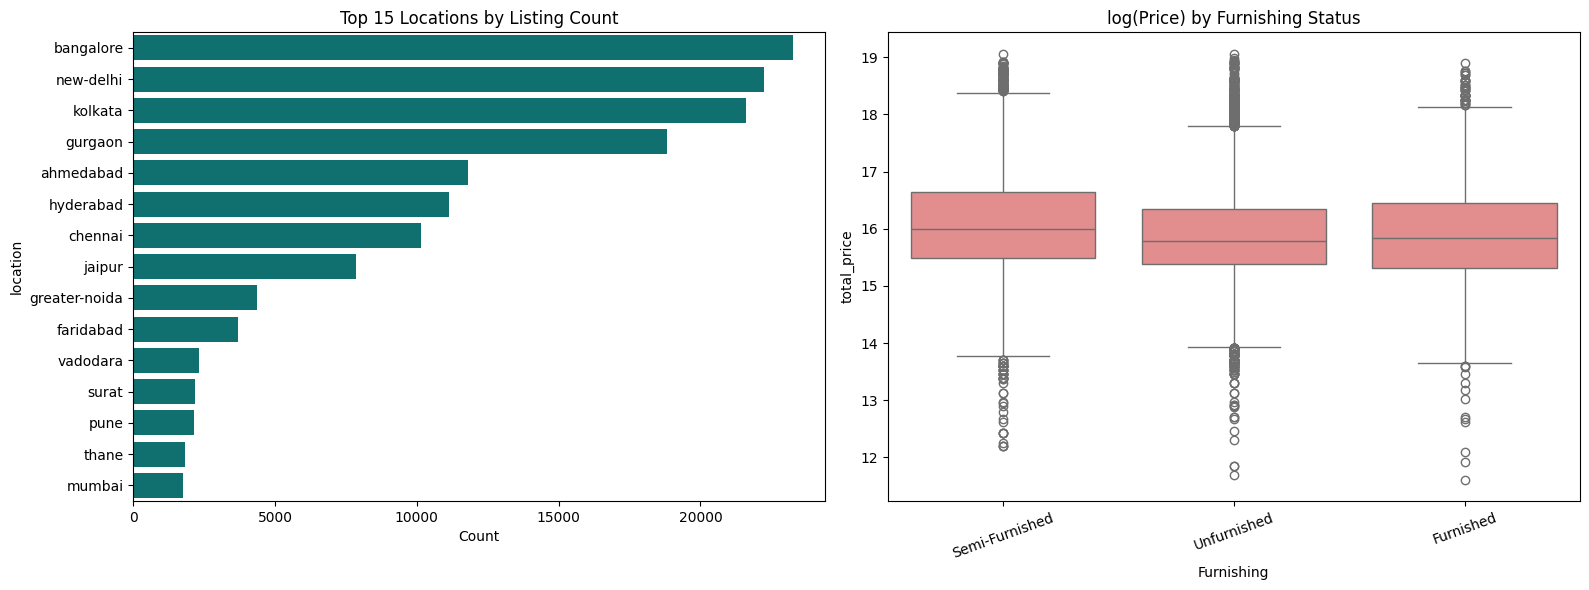

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_locations = df_clean['location'].value_counts().head(15)
sns.barplot(x=top_locations.values, y=top_locations.index, ax=axes[0], color='teal')
axes[0].set_title('Top 15 Locations by Listing Count')
axes[0].set_xlabel('Count')

furn_order = df_clean['Furnishing'].value_counts().index
sns.boxplot(data=df_clean, x='Furnishing', y=np.log1p(df_clean['total_price']),
            order=furn_order, ax=axes[1], color='lightcoral')
axes[1].set_title('log(Price) by Furnishing Status')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


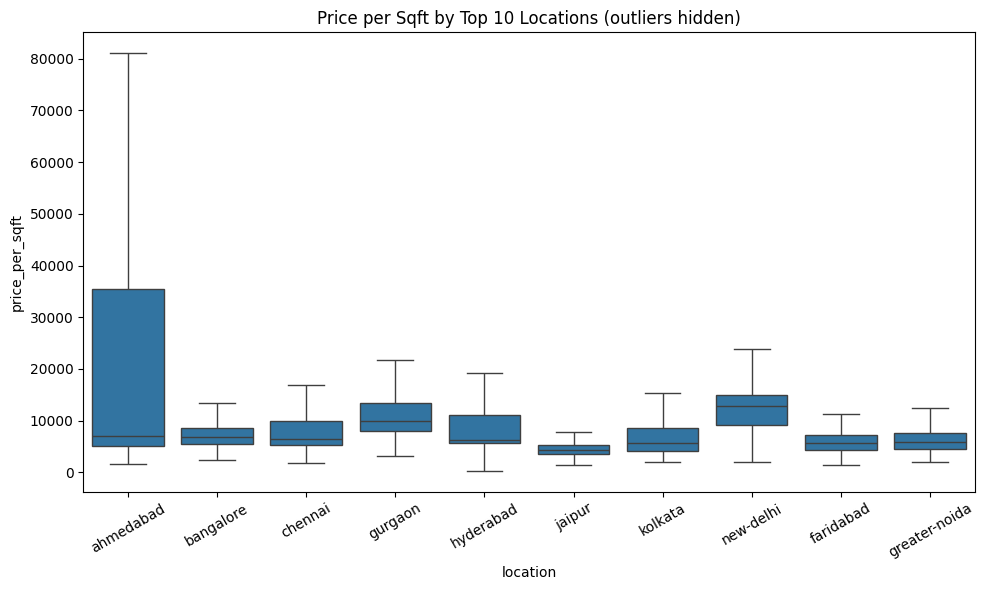

In [14]:
plt.figure(figsize=(10,6))
top10 = df_clean['location'].value_counts().head(10).index
sns.boxplot(data=df_clean[df_clean['location'].isin(top10)],
            x='location', y='price_per_sqft', showfliers=False)
plt.title('Price per Sqft by Top 10 Locations (outliers hidden)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Observation:** location is a major price driver — price-per-sqft varies several-fold between
the top markets. Furnished and semi-furnished properties also command a visible premium over
unfurnished ones.


## 5. Relationship Between Area, Bedrooms and Price


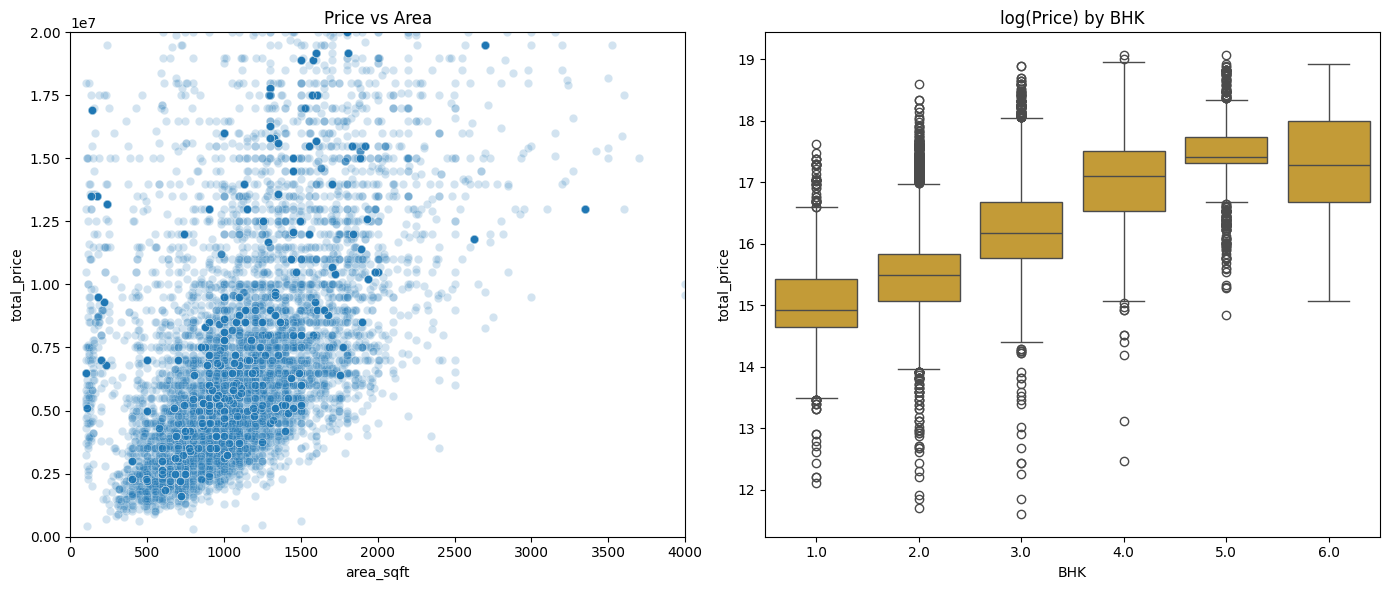

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sample = df_clean.sample(min(20000, len(df_clean)), random_state=42)
sns.scatterplot(data=sample, x='area_sqft', y='total_price', alpha=0.2, ax=axes[0])
axes[0].set_title('Price vs Area')
axes[0].set_ylim(0, 2e7)
axes[0].set_xlim(0, 4000)

sns.boxplot(data=df_clean[df_clean['BHK'] <= 6], x='BHK', y=np.log1p(df_clean['total_price']),
            ax=axes[1], color='goldenrod')
axes[1].set_title('log(Price) by BHK')

plt.tight_layout()
plt.show()


## 6. Correlation Heatmap (numeric features)


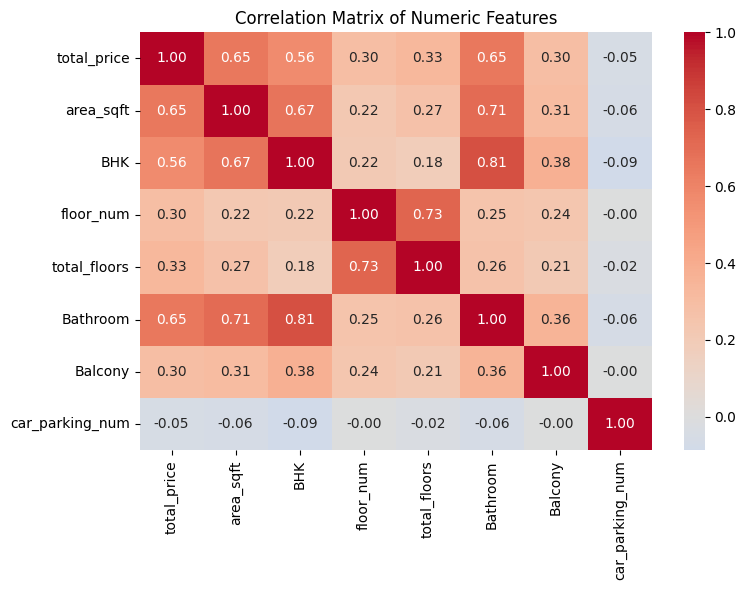

In [16]:
num_cols = ['total_price','area_sqft','BHK','floor_num','total_floors',
            'Bathroom','Balcony','car_parking_num']
corr = df_clean[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()


**Observation:** `area_sqft`, `BHK` and `Bathroom` are the strongest numeric correlates of
price, and unsurprisingly correlate with each other too (bigger flats have more rooms/baths).
`floor_num` / `total_floors` and `car_parking_num` have weak linear correlation with price —
their effect, if any, is likely non-linear or location-dependent, which favors a tree-based
model over plain linear regression.


## 10. Save Cleaned Data

Save `df_clean` to disk so it can be reused in `Model_Training.ipynb` without re-running this notebook.

In [17]:
df_clean.to_pickle("df_clean.pkl")
print("Saved df_clean.pkl with shape:", df_clean.shape)


Saved df_clean.pkl with shape: (173129, 28)
